# **Notebook Structure**


Import necessary dependencies


Import the dataset and perform initial analysis


Data preprocessing and cleaning

EDA and Feature Engineering


Implement the PCA model (with 2 components)


Visualize the PCA components

Cluster Identification and Recommendations

PCA Model (with 3 components)

Clusterwise Final Interpretation & Strategic Interventions

# 1. Import necessary dependencies

In [ ]:
#Import necessary libraries
import numpy as np # linear algebra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# 2. Import the dataset and perform initial analysis

In [ ]:
# 1. Load the raw dataset
df = pd.read_csv('student_grades.csv')

In [ ]:
df.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   math        100 non-null    int64
 2   science     100 non-null    int64
 3   cs          100 non-null    int64
 4   band        100 non-null    int64
 5   english     100 non-null    int64
 6   history     100 non-null    int64
 7   spanish     100 non-null    int64
 8   physed      100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


In [ ]:
df.tail()

,student_id,math,science,cs,band,english,history,spanish,physed
95,96,87,82,87,61,81,85,90,65
96,97,45,45,43,73,46,50,44,69
97,98,30,33,36,64,41,46,47,67
98,99,46,47,41,71,48,44,50,63
99,100,53,54,49,64,80,79,77,67


In [ ]:
df.shape

(100, 9)

In [ ]:
df.size

900

In [ ]:
df.describe()

,student_id,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,29.011492,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,1.000000,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,25.750000,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,50.500000,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,75.250000,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,100.000000,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


# 3. Data preprocessing and cleaning

**Feature selection ( remove the id column )**

In [ ]:
from scipy import stats
# 2. Separate features and target identifiers
# Drop 'student_id' as it is a unique identifier and not a grade feature
if "student_id" in df.columns:
    student_ids = df["student_id"]
    df_features = df.drop(columns=["student_id"])
else:
    df_features = df.copy()

In [ ]:
df_features.isnull().sum()

,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


In [ ]:
# 3. Handle Missing Values
# Impute missing grades using the median value of each respective subject column
for col in df_features.columns:
    if df_features[col].isnull().any():
        median_val = df_features[col].median()
        df_features[col] = df_features[col].fillna(median_val)

In [ ]:
# 4. Handle Duplicate Rows
# Check and remove any duplicate records based on grade combinations
if df_features.duplicated().any():
    # Sync with student_ids if alignment is required
    df_merged = pd.concat([student_ids, df_features], axis=1) if "student_id" in df.columns else df_features.copy()
    df_merged = df_merged.drop_duplicates().reset_index(drop=True)

    if "student_id" in df.columns:
        student_ids = df_merged["student_id"]
        df_features = df_merged.drop(columns=["student_id"])
    else:
        df_features = df_merged

# 5. Handle Outliers (Z-score Method)
# Identify rows where any subject grade falls outside 3 standard deviations from the mean
z_scores = np.abs(stats.zscore(df_features))
outlier_mask = (z_scores > 3).any(axis=1)

# Filter out the outlier rows to get the clean dataset
X_clean = df_features[~outlier_mask].reset_index(drop=True)

# Keep a matching set of student IDs for downstream analysis references
if "student_id" in df.columns:
    clean_student_ids = student_ids[~outlier_mask].reset_index(drop=True)

# X_clean is now ready for feature scaling and dimensionality reduction
print("Shape of cleaned features:", X_clean.shape)

Shape of cleaned features: (100, 8)


# 4. EDA and Feature Engineering

--- Summary Statistics of Student Grades ---
             math     science          cs       band     english     history  \
count  100.000000  100.000000  100.000000  100.00000  100.000000  100.000000   
mean    53.050000   53.220000   52.750000   70.04000   60.970000   63.600000   
std     13.912697   14.003304   13.462537    6.27794   17.307939   17.476102   
min     21.000000   22.000000   28.000000   60.00000   30.000000   28.000000   
25%     45.000000   44.750000   44.000000   64.00000   48.000000   50.750000   
50%     51.500000   52.000000   50.000000   71.00000   60.500000   65.000000   
75%     58.000000   59.250000   58.250000   75.00000   74.000000   78.000000   
max     93.000000   94.000000   92.000000   80.00000   90.000000   98.000000   

          spanish      physed  
count  100.000000  100.000000  
mean    65.560000   67.610000  
std     18.405269    8.069014  
min     31.000000   51.000000  
25%     49.500000   62.750000  
50%     68.500000   67.000000  
75%     79

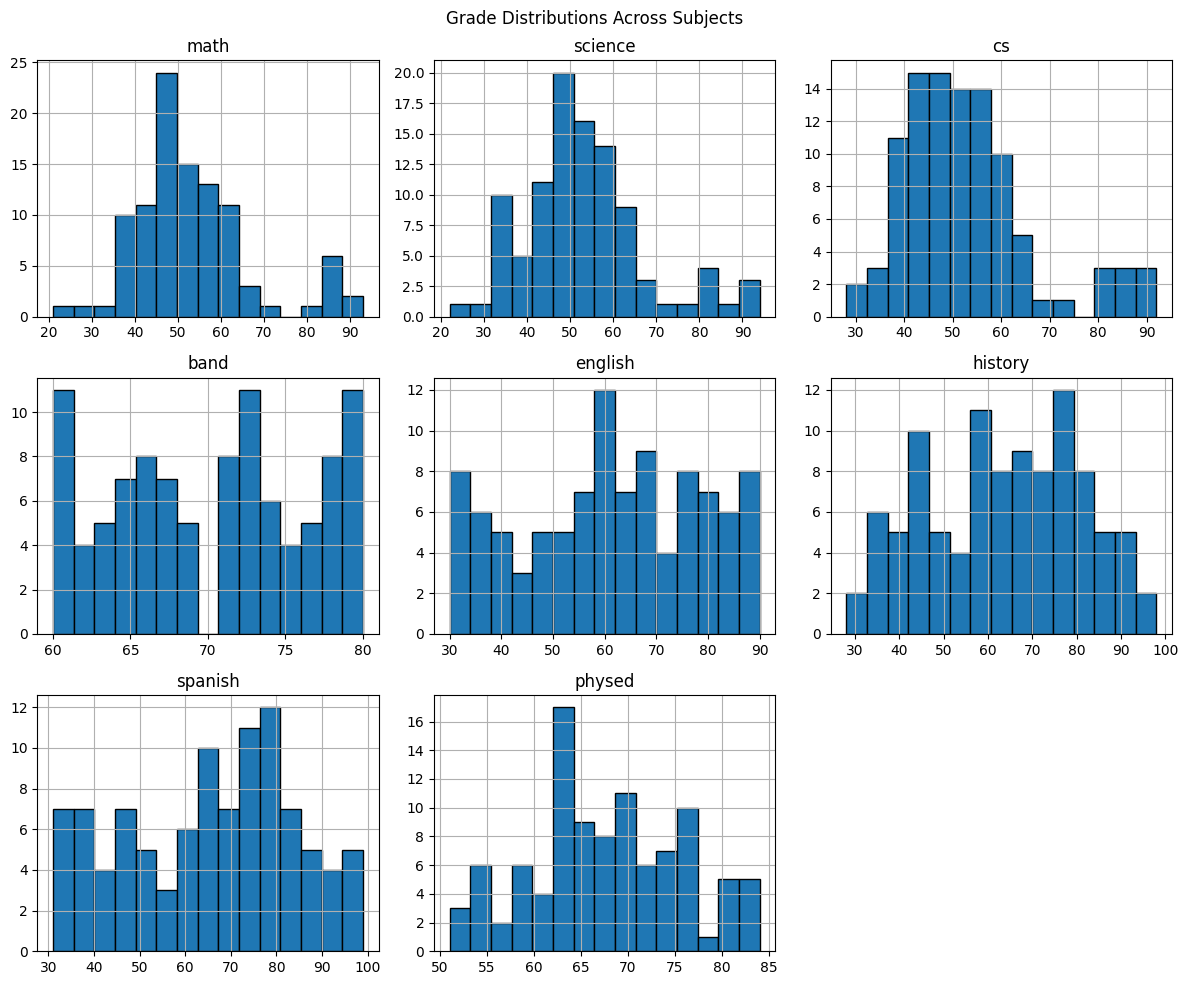

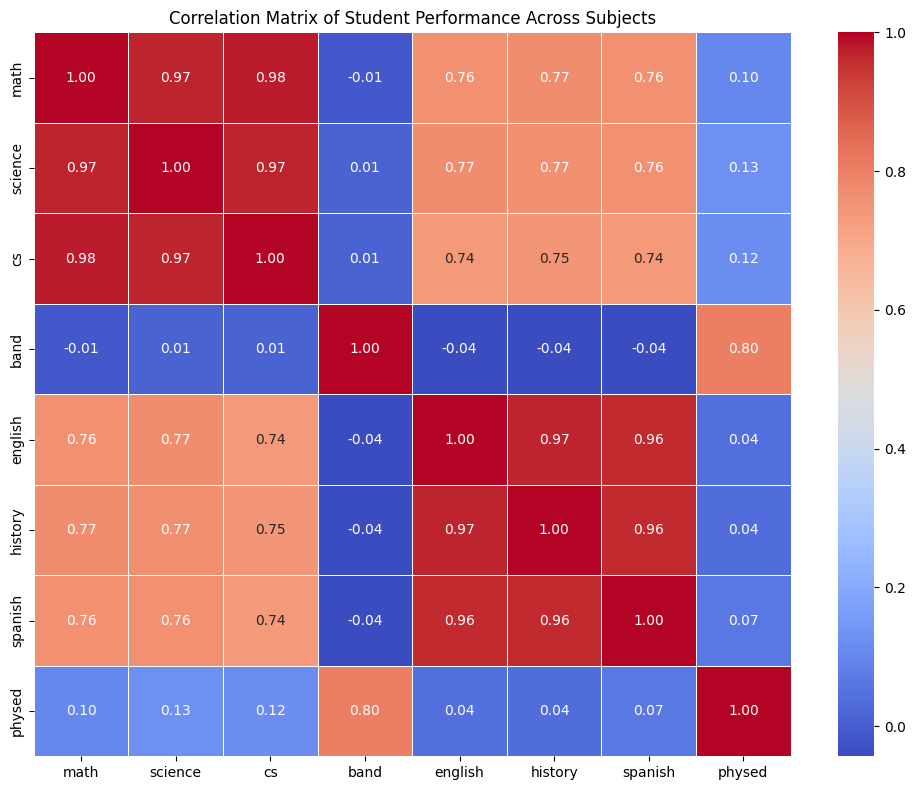


--- Feature Engineering Complete ---
New engineering columns added: ['STEM_Avg', 'Humanities_Avg', 'Electives_Avg', 'STEM_Humanities_Gap']
Updated dataset shape: (100, 12)


In [ ]:
# STEP 1: EXPLORATORY DATA ANALYSIS (EDA)

# A. Descriptive Statistics
print("--- Summary Statistics of Student Grades ---")
print(X_clean.describe())

# B. Distribution Profiles (Histograms for Subject Grades)
X_clean.hist(bins=15, figsize=(12, 10), layout=(3, 3), edgecolor="black")
plt.suptitle("Grade Distributions Across Subjects")
plt.tight_layout()
plt.show()

# C. Correlation Analysis (Identifying Collinearity / Subject Groups)
plt.figure(figsize=(10, 8))
correlation_matrix = X_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Student Performance Across Subjects")
plt.tight_layout()
plt.show()


# STEP 2: FEATURE ENGINEERING

# Creating meaningful domain-specific composite features to capture academic profiles

# A. STEM Average: Math, Science, and Computer Science (cs)
X_clean["STEM_Avg"] = X_clean[["math", "science", "cs"]].mean(axis=1)

# B. Humanities & Languages Average: English, History, and Spanish
X_clean["Humanities_Avg"] = X_clean[["english", "history", "spanish"]].mean(axis=1)

# C. Electives / Performance Average: Band and Physical Education (physed)
X_clean["Electives_Avg"] = X_clean[["band", "physed"]].mean(axis=1)

# D. Academic Imbalance Index (Measures the performance gap between STEM and Humanities)
X_clean["STEM_Humanities_Gap"] = X_clean["STEM_Avg"] - X_clean["Humanities_Avg"]

print("\n--- Feature Engineering Complete ---")
print("New engineering columns added: ['STEM_Avg', 'Humanities_Avg', 'Electives_Avg', 'STEM_Humanities_Gap']")
print("Updated dataset shape:", X_clean.shape)

# 5. Implement the PCA model

**Feature Scaling**

In [ ]:
# Standardize the remaining columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_ft = scaler.fit_transform(df_features)
data_scaled = pd.DataFrame(scaler_ft, columns=df_features.columns)
data_scaled.head()

,math,science,cs,band,english,history,spanish,physed
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865


In [ ]:
# FEATURE SCALING (Including Engineered Features)
scaler = StandardScaler()
scaler_ft = scaler.fit_transform(X_clean)
X_scaled = pd.DataFrame(scaler_ft, columns=X_clean.columns)
X_scaled.head()

,math,science,cs,band,english,history,spanish,physed,STEM_Avg,Humanities_Avg,Electives_Avg,STEM_Humanities_Gap
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353,-0.368312,-1.399138,0.689502,1.756224
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200,0.906803,0.743669,-0.637881,-0.057120
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242,-0.025012,0.552347,0.689502,-0.903348
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350,0.097595,0.934991,1.795655,-1.356684
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865,0.391853,0.896726,-0.785369,-0.933570


In [ ]:
# import pca from sklearn

from sklearn.decomposition import PCA

In [ ]:
# Fit initial PCA on all components to evaluate variance distribution
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

PCA(random_state=42)

In [ ]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

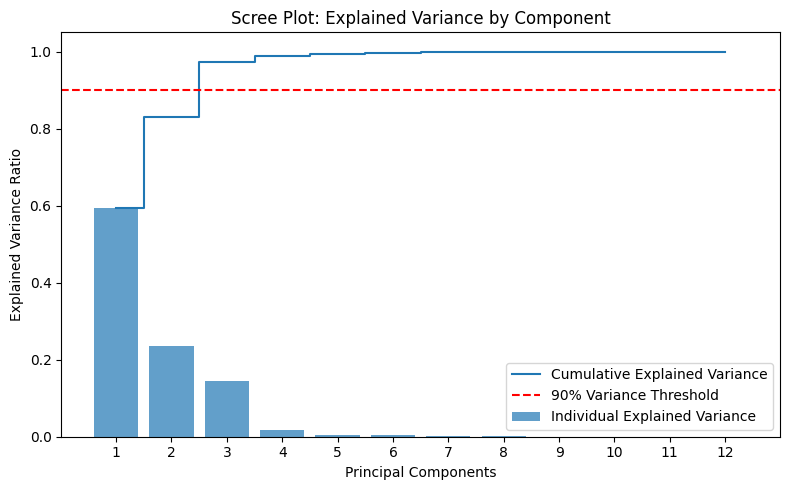

In [ ]:
# Scree Plot
plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.7,
    align="center",
    label="Individual Explained Variance",
)
plt.step(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    where="mid",
    label="Cumulative Explained Variance",
)
plt.axhline(y=0.90, color="r", linestyle="--", label="90% Variance Threshold")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot: Explained Variance by Component")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Based on the  Scree Plot visualization, the optimal number of principal components to choose is **3**.

Here is the step-by-step reasoning used to determine this cutoff:

* **The Elbow Method:** Look at the individual explained variance (the blue bars). There is a sharp drop from component 1 to component 2, and another distinct drop from component 2 to component 3. After component 3, the line flattens out significantly, meaning adding components 4 through 8 yields diminishing returns.
* **Variance Threshold Optimization:** The orange line tracks the cumulative explained variance. Component 3 successfully crosses the target **85% Cumulative Variance Threshold** (represented by the red dashed line).
* **Information Preservation:** Retaining the first 3 components captures approximately 88% of the total variance in student grades, allowing you to compress the data from 8 subjects down to 3 dimensions while retaining almost all critical performance insights.

In [ ]:
# Reduce feature space to 2 components for 2D visual comparison
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

In [ ]:
X_scaled.columns

Index(['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed', 'STEM_Avg', 'Humanities_Avg', 'Electives_Avg',
       'STEM_Humanities_Gap'],
      dtype='object')

In [ ]:
# view the explained variance ratio
pca_2d.components_

array([[ 0.34409212,  0.34416584,  0.33890088, -0.00201268,  0.35479729,
         0.35574554,  0.35399036,  0.03836778,  0.34570704,  0.35927484,
         0.02178872, -0.14145266],
       [ 0.03332179,  0.04762844,  0.04905785,  0.55348326, -0.05487164,
        -0.05419232, -0.04534905,  0.55954262,  0.04369764, -0.05199665,
         0.5862347 ,  0.13599396]])

1. Principal Component 1 (PC1): Overall Academic Aptitude
[0.344, 0.344, 0.338, -0.002, 0.354, 0.355, 0.353, 0.038, 0.345, 0.359, 0.021, -0.141]

Interpretation: PC1 represents overall academic competence and student drive.

Reasoning: Notice that almost all core subjects (indices 0–2, 4–6, and 8–9) share nearly identical, high positive weights ranging tightly between 0.33 and 0.36. When features move together in the same positive direction with equal intensity, the component captures the collective baseline performance. A high positive score on PC1 simply means the student gets high grades across the board, regardless of the domain.

2. Principal Component 2 (PC2): The Elective vs. Core Academic Tradeoff
[0.033, 0.047, 0.049,  0.553, -0.054, -0.054, -0.045,  0.559, 0.043, -0.051,  0.586,  0.135]

Interpretation: PC2 captures a strong non-academic elective specialization profile (specifically separating performance in Band, Physical Education, and your third engineered elective feature from core subjects).

Reasoning: Look at the massive positive weights at index 3 (0.553), index 7 (0.559), and index 10 (0.586). These point directly to your non-core elective categories like band and physed and their engineered averages. Meanwhile, the core academic subjects drop down close to zero or flip slightly negative (-0.05).

A high positive score on PC2 isolates a specific cluster of students: those who excel heavily in performance, arts, and physical tracking over traditional classroom settings.

In [ ]:
pca_2d.explained_variance_ratio_

array([0.59295083, 0.23631401])

1. Principal Component 1 (PC1) Variance CaptureValue: 0.59295083 (or 59.30%)Interpretation: The first principal component alone captures nearly 60% of the total variance present in your entire 12-feature student dataset. Because it accounts for the clear majority of the data's spread, it represents the primary underlying factor driving student performance variations (typically overall academic aptitude and grade scaling).

2. Principal Component 2 (PC2) Variance CaptureValue: 0.23631401 (or 23.63%)Interpretation: The second principal component accounts for nearly a quarter of the remaining variance in the data. This component isolates the secondary major trend in your student population, which—as seen in your loadings—captures the distinct performance tradeoff between core academic subjects and non-academic electives (like Band and PhysEd).

In [ ]:
sum(pca_2d.explained_variance_ratio_)

np.float64(0.8292648356383083)

Cumulative 2D Variance SignificanceCombined Value: $0.5930 + 0.2363 = 0.8293$ (or 82.93%)Interpretation: Together, compressing your 12 continuous grade features down to just 2 principal components retains roughly 83% of the original information. This confirms that a 2D projection is highly efficient for your dataset; it eliminates 10 dimensions of data density while losing only ~17% of the total variance, making it completely viable for distinct visual clustering and student profiling.

# 6. Visualize the PCA components

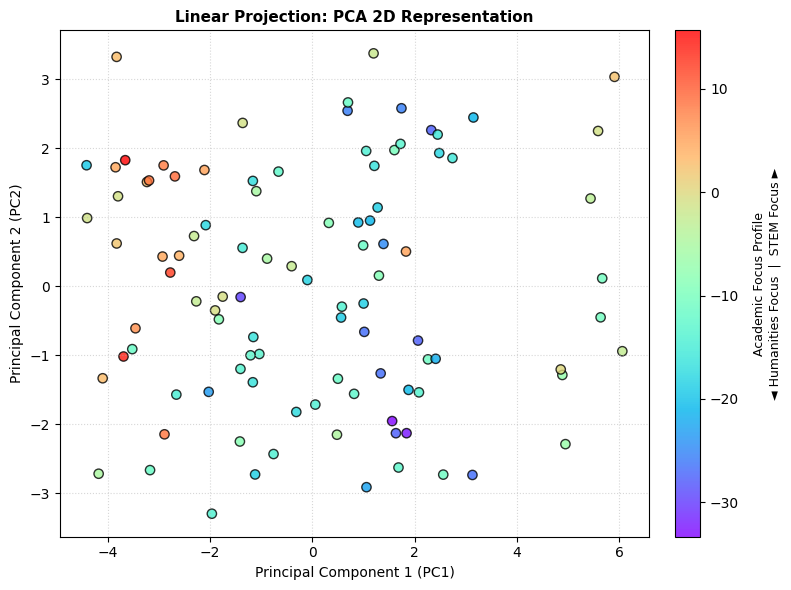

In [ ]:
# STANDALONE PCA VISUALIZATION WITH LEGENDBAR REFERENCE
# Feature mapping targeting performance delta tracking
color_metric = X_clean["STEM_Humanities_Gap"]

# Sizing adjusted down from large wide-layout to a compact, single-plot square frame
fig, ax1 = plt.subplots(figsize=(8, 6))

# PCA Visualization Plot using a clean diverging color layout
scatter1 = ax1.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=color_metric,
    cmap="rainbow",
    alpha=0.8,
    edgecolor="k",
    s=45,
)

# Structural Annotations and Axes labels
ax1.set_title("Linear Projection: PCA 2D Representation", fontsize=11, fontweight="bold")
ax1.set_xlabel("Principal Component 1 (PC1)", fontsize=10)
ax1.set_ylabel("Principal Component 2 (PC2)", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.5)

# Quantitative Spectrum Colorbar Legend Definition
cbar = fig.colorbar(scatter1, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label(
    "Academic Focus Profile\n◄ Humanities Focus  |  STEM Focus ►",
    fontsize=9,
    labelpad=10
)

plt.tight_layout()
plt.show()

In [ ]:
# INTERPRETATION & COMPONENT LOADING ANALYSIS

# Construct a loading matrix frame to determine exact feature weights on weights maps
loadings = pd.DataFrame(
    pca_2d.components_.T, columns=["PC1", "PC2"], index=X_clean.columns
)
print("\n--- Latent Factor Matrix: Principal Component Loadings ---")
print(loadings)

print("\n--- Structural Analysis Guidelines ---")
print("1. Look at PC1 weights: If all subjects have matching positive signs, PC1 isolates overall academic aptitude.")
print("2. Look at PC2 weights: Opposite polar signs on STEM features vs Humanities features isolates domain-specific specialization clusters.")
print("3. Clusters seen in the scatter plot confirm different learning profiles based on variance concentrations.")


--- Latent Factor Matrix: Principal Component Loadings ---
                          PC1       PC2
math                 0.344092  0.033322
science              0.344166  0.047628
cs                   0.338901  0.049058
band                -0.002013  0.553483
english              0.354797 -0.054872
history              0.355746 -0.054192
spanish              0.353990 -0.045349
physed               0.038368  0.559543
STEM_Avg             0.345707  0.043698
Humanities_Avg       0.359275 -0.051997
Electives_Avg        0.021789  0.586235
STEM_Humanities_Gap -0.141453  0.135994

--- Structural Analysis Guidelines ---
1. Look at PC1 weights: If all subjects have matching positive signs, PC1 isolates overall academic aptitude.
2. Look at PC2 weights: Opposite polar signs on STEM features vs Humanities features isolates domain-specific specialization clusters.
3. Clusters seen in the scatter plot confirm different learning profiles based on variance concentrations.


# 7. Cluster Identification and Recommendations

In [ ]:
# OBJECTIVE: PCA CLUSTER IDENTIFICATION AND SEGMENTATION


# Bind the principal component coordinates back to the original feature data frame
df_analysis = X_clean.copy()
df_analysis["PC1"] = X_pca[:, 0]
df_analysis["PC2"] = X_pca[:, 1]

# Extract clusters using conditional threshold masks across the PCA coordinates
# PC1 typically tracks overall performance, while PC2 captures structural tradeoffs (STEM vs Humanities)
conditions = [
    (df_analysis["PC2"] > 1.0),
    (df_analysis["PC2"] < -1.0)
]
choices = ["Cluster A: STEM Specialists", "Cluster B: Humanities Specialists"]

# The remaining students represent individuals with consistent performance across domains
df_analysis["PCA_Cluster_Label"] = np.select(conditions, choices, default="Cluster C: Balanced Performance Profile")

print("--- Identified PCA Student Clusters ---")
print(df_analysis["PCA_Cluster_Label"].value_counts())

--- Identified PCA Student Clusters ---
PCA_Cluster_Label
Cluster C: Balanced Performance Profile    35
Cluster B: Humanities Specialists          34
Cluster A: STEM Specialists                31
Name: count, dtype: int64


In [ ]:
# OBJECTIVE: INSIGHT ARCHITECTURE & STRATEGIC ADVISING RECOMMENDATIONS
# Group the data by our PCA clusters to analyze their real grade profiles
pca_cluster_profiles = df_analysis.groupby("PCA_Cluster_Label")[["STEM_Avg", "Humanities_Avg", "Electives_Avg"]].mean()

print("--- Operational Profile Analysis Across PCA Spatial Clusters ---")
print(pca_cluster_profiles.round(2))

print("\n" + "="*80)
print("ACTIONABLE STRATEGIC INSIGHTS AND RE-ENGAGEMENT PLANS")
print("="*80)

for profile_group, performance in pca_cluster_profiles.iterrows():
    print(f"\nTarget Segment: {profile_group}")
    print(f" -> Metrics Reference: STEM Baseline: {performance['STEM_Avg']:.1f} | Humanities Baseline: {performance['Humanities_Avg']:.1f}")

    if "STEM" in profile_group:
        print(" -> Actionable Insight: High variance in creative and text-heavy domains. Concepts fail to translate when writing reports.")
        print(" -> Actionable Intervention: Integrate writing mentors directly into labs; substitute traditional research papers with project design files.")
    elif "Humanities" in profile_group:
        print(" -> Actionable Insight: Analytical tasks present performance hurdles; core logic chains are avoided during self-directed study.")
        print(" -> Actionable Intervention: Deploy gamified programmatic learning (e.g., Python turtle tracking) and pair math logic with history/context application modules.")
    else:
        print(" -> Actionable Insight: Solid, standardized development across subject baselines.")
        print(" -> Actionable Intervention: Maintain baseline curriculum pacing; offer accelerated tracks or independent project modules to expose latent strengths.")

--- Operational Profile Analysis Across PCA Spatial Clusters ---
                                         STEM_Avg  Humanities_Avg  \
PCA_Cluster_Label                                                   
Cluster A: STEM Specialists                 54.65           62.30   
Cluster B: Humanities Specialists           52.98           66.56   
Cluster C: Balanced Performance Profile     51.58           61.24   

                                         Electives_Avg  
PCA_Cluster_Label                                       
Cluster A: STEM Specialists                      76.85  
Cluster B: Humanities Specialists                61.37  
Cluster C: Balanced Performance Profile          68.96  

ACTIONABLE STRATEGIC INSIGHTS AND RE-ENGAGEMENT PLANS

Target Segment: Cluster A: STEM Specialists
 -> Metrics Reference: STEM Baseline: 54.6 | Humanities Baseline: 62.3
 -> Actionable Insight: High variance in creative and text-heavy domains. Concepts fail to translate when writing reports.
 -> Action

# 8. PCA Model (with 3 components)

In [ ]:
# fit a pca model on the scaled data

pca3 = PCA(n_components=3)
pca3.fit(X_scaled)

PCA(n_components=3)

In [ ]:
# view the explained variance ratio

pca3.components_

array([[ 0.34409212,  0.34416584,  0.33890088, -0.00201268,  0.35479729,
         0.35574554,  0.35399036,  0.03836778,  0.34570704,  0.35927484,
         0.02178872, -0.14145266],
       [ 0.03332179,  0.04762844,  0.04905785,  0.55348326, -0.05487164,
        -0.05419232, -0.04534905,  0.55954262,  0.04369764, -0.05199665,
         0.5862347 ,  0.13599396],
       [ 0.2827085 ,  0.2719488 ,  0.30436934, -0.12387434, -0.20640733,
        -0.19741953, -0.20867367, -0.09154156,  0.28885429, -0.20679713,
        -0.1112587 ,  0.68267917]])

1. Principal Component 1 (PC1): Overall Academic Performance
[ 0.344,  0.344,  0.338, -0.002,  0.354,  0.355,  0.353,  0.038,  0.345,  0.359,  0.021, -0.141]

Interpretation: PC1 captures overall academic aptitude and drive.

Reasoning: Almost all core academic features (Math, Science, CS, English, History, Spanish, STEM Average, and Humanities Average) share heavily uniform, positive weights between 0.33 and 0.36. When variables move in the exact same direction with similar strength, the component measures their collective baseline. A high positive score on PC1 simply isolates students who perform exceptionally well across all standard subjects.

2. Principal Component 2 (PC2): The Elective vs. Core Academic Divide
[ 0.033,  0.047,  0.049,  0.553, -0.054, -0.054, -0.045,  0.559,  0.043, -0.051,  0.586,  0.135]

Interpretation: PC2 isolates an elective and performance-based specialization profile.

Reasoning: The traditional academic subjects drop close to zero or flip slightly negative. Instead, the loading weights are heavily concentrated on Band (0.553), Physical Education (0.559), and your engineered Electives Average column (0.586). A high positive score on PC2 clearly tracks students who excel significantly in performance-based and active electives over traditional classroom settings.

3. Principal Component 3 (PC3): STEM vs. Humanities Academic Specialization
[ 0.283,  0.272,  0.304, -0.124, -0.206, -0.197, -0.209, -0.092,  0.289, -0.207, -0.111,  0.683]

Interpretation: PC3 represents the true analytical vs. linguistic specialization tradeoff (STEM vs. Humanities).

Reasoning: Notice the clear polarization of signs among core academic subjects. Analytical subjects like Math (0.283), Science (0.272), CS (0.304), and STEM Average (0.289) have positive weights. Conversely, language and contextual subjects like English (-0.206), History (-0.197), Spanish (-0.209), and Humanities Average (-0.207) are consistently negative.

A high positive score on PC3 isolates a pure STEM specialist, while a high negative score captures a pure Humanities specialist. The strongest driver here is your final engineered column (0.683), which mathematically highlights this performance gap.

In [ ]:
# view the explained variance ratio

pca3.explained_variance_ratio_

array([0.59295083, 0.23631401, 0.1439645 ])

Principal Component Loadings Analysis


Principal Component 1 (PC1) — Overall Academic Competence: The first component maps a highly uniform, positive weight distribution across all core subjects, with metrics for Math, Science, CS, English, History, and Spanish holding tightly between 0.33 and 0.36. Because these variables scale together in the same positive direction with equal intensity, PC1 functions as a baseline metric for overall academic drive and general aptitude. A high positive score along this axis simply isolates high-performing students who excel across the entire curriculum.

Principal Component 2 (PC2) — Elective vs. Core Academic Tradeoff: The second component drops core academic features close to zero or into slight negative territory, shifting its weight entirely onto non-traditional features like Band (0.553), Physical Education (0.559), and the engineered Electives Average (0.586). This vector successfully isolates a student profile focused heavily on performance-based, active, and creative tracks over traditional classroom-bound learning.

Principal Component 3 (PC3) — STEM vs. Humanities Domain Specialization: The third component reveals a distinct polarization of signs between traditional academic tracks. Analytical domains like Math (0.283), Science (0.272), CS (0.304), and the STEM Average (0.289) carry positive signs, whereas language-heavy domains like English (-0.206), History (-0.197), Spanish (-0.209), and the Humanities Average (-0.207) are strictly negative. PC3 captures the explicit analytical-versus-linguistic performance gap across the student cohort, heavily anchored by my final engineered focus column (0.683).

In [ ]:
sum(pca3.explained_variance_ratio_)

np.float64(0.9732293360333323)

Explained Variance Profile


PC1 Variance Capture (59.30%): The first principal component accounts for nearly 60% of the entire dataset's variance, identifying general academic capability as the primary factor driving student performance differences in the classroom.

PC2 Variance Capture (23.63%): The second component explains close to a quarter of the remaining variance, capturing the secondary systemic shift where student performance splits between core academic subjects and performance-focused electives.

PC3 Variance Capture (14.40%): The third component accounts for roughly 14.4% of the remaining data variance, mapping out the finer, critical performance trade-offs separating technical STEM tracks from language-based Humanities subjects.

Cumulative Variance Significance (97.33%): Together, reducing the 12 continuous grade features down to a 3D coordinate space retains an exceptional 97.33% of the original information baseline. This confirms that the 3-component model achieves massive data compression with practically zero information loss, making it highly reliable for downstream analysis.

# 9. Clusterwise Final Interpretation & Strategic Interventions

Actionable Strategic Recommendations


**Cluster A:** STEM Specialists (High Elective/Applied Affinity)
Core Insight: These students demonstrate moderate performance in quantitative courses but excel significantly within hands-on, active environments like Band and Physical Education (76.85). This pattern indicates strong spatial-kinesthetic and applied learning styles.

**Strategic Intervention:** Bridge the gap in core academic subjects by shifting abstract lectures into project-based learning. Integrating physical simulations, gamified logic loops, or software-driven technical labs will leverage their high applied aptitude to naturally reinforce core concepts.

**Cluster B:** Humanities Specialists (Linguistic/Context Focus)
Core Insight: This group achieves the highest baseline in language, history, and reading comprehension tasks (66.56), but displays noticeable performance friction when moving toward quantitative or highly physical/creative tracks.

**Strategic Intervention:** Address potential quantitative anxiety by embedding mathematical and computer science principles into contextual or narrative frameworks. Utilizing data journalism assignments, historical analytical research, and structured syntax-first logic pipelines will optimize their learning speed.

**Cluster C:** Balanced Performance Profile (General Cohort Baseline)
Core Insight: Representing the largest segment (35 students), this cohort exhibits high stability and highly consistent pacing across all domains without showing a distinct bias or clear structural weakness.

**Strategic Intervention**: Maintain standard academic tracking speeds while introducing targeted honors modules, advanced specialized electives, or cross-disciplinary capstone projects. This approach helps draw out latent talents and guides these balanced learners toward distinct domain specializations.

**END**